# **Handling Missing Values - Complete Case Analysis (CCA)**

## Roadmap

### **1. Introduction**
- What is Complete Case Analysis?
- When to Use CCA

### **2. Load Dataset**

### **3. Identify Columns with Low Missing Values**

### **4. Apply Complete Case Analysis**

### **5. Compare Data Before vs After CCA**
- Distribution Comparison
- Categorical Distribution Comparison

### **6. Key Revision Notes**


## **Imports and Dataset Loading**
Load the required libraries and dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("docs/Lecture-022-data_science_job.csv")
df.head()

In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


## **Identify Suitable Columns**

Complete Case Analysis works best when the percentage of missing values is small (typically <5%).


In [2]:
missing_pct = df.isnull().mean() * 100
missing_pct

cca_cols = [col for col in df.columns
            if 0 < df[col].isnull().mean() < 0.05]

cca_cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

## **Apply Complete Case Analysis**

Rows containing missing values in the selected columns are removed.


In [3]:
cca_df = df[cca_cols].dropna()

print("Original Shape:", df.shape)
print("After CCA:", cca_df.shape)
print("Rows Retained:", round(len(cca_df) / len(df) * 100, 2), "%")

Original Shape: (19158, 13)
After CCA: (17182, 5)
Rows Retained: 89.69 %


## **Compare Numerical Distributions**
Check whether removing missing rows changes the data distribution.

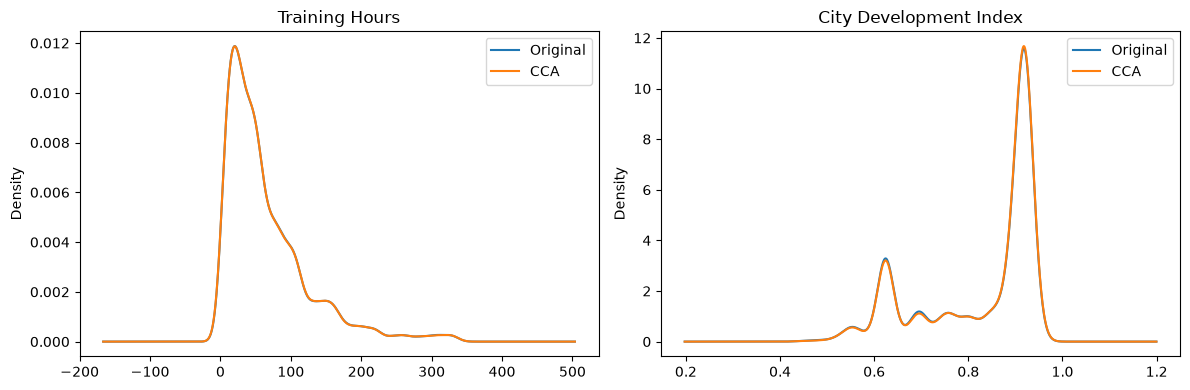

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df["training_hours"].plot(kind="density", ax=axes[0], label="Original")
cca_df["training_hours"].plot(kind="density", ax=axes[0], label="CCA")
axes[0].set_title("Training Hours")
axes[0].legend()

df["city_development_index"].plot(kind="density", ax=axes[1], label="Original")
cca_df["city_development_index"].plot(kind="density", ax=axes[1], label="CCA")
axes[1].set_title("City Development Index")
axes[1].legend()

plt.tight_layout()

## **Compare Categorical Distribution**
Verify that category proportions remain similar after CCA.

In [5]:
comparison = pd.concat(
    [
        df["education_level"].value_counts(normalize=True),
        cca_df["education_level"].value_counts(normalize=True)
    ],
    axis=1,
    keys=["Original", "CCA"]
)

comparison

,Original,CCA
education_level,,
Graduate,0.620280,0.619835
Masters,0.233234,0.234082
High School,0.107872,0.107380
Phd,0.022141,0.022116
Primary School,0.016472,0.016587


## **Key Revision Notes**

- **Complete Case Analysis (CCA)** removes rows containing missing values.
- Best used when missing values are **few (≈ <5%)** and **Missing Completely at Random (MCAR)**.
- Simple to implement and supported by most ML workflows.
- Reduces dataset size, which may decrease model performance if many rows are removed.
- Always compare feature distributions before and after CCA to ensure minimal information loss.
- Avoid CCA when missing values are large or systematic.
